# HDC Language Recognition

Notebook front-end for `hdc.py` / `encoder.py` / `hdc_train.py`.

`hdc`: IM generation, bind/permute

`encoder`: N-gram encoding using bind/permute; bundling, using accumulation

`hdc_train`: training, classification

In [ ]:
import os
import sys

# Notebook lives in notebooks/; repo root holds src/ (library modules) and the
# data directories (e.g. language_recognition_dataset, UWaveGestureLibraryAll)
# that DATA_DIR constants below resolve relative to cwd.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count

import hdc
from encoder import encode_text_to_hv
import hdc_train as t

## Quick sanity check

Train a single language at a small dimension and look at the resulting class hypervector, just to confirm the pipeline behaves before committing to the full sweep.

In [2]:
D, N = 500, 3
item_memory = hdc.generate_item_memory(t.ALPHABET, D, seed=42)
danish_text = t.load_training_text('dan')
danish_hv = encode_text_to_hv(danish_text, item_memory, N, D)

print(f"Danish class hypervector shape: {danish_hv.shape}")
print(f"First 50 bits: {danish_hv[:50]}")

Danish class hypervector shape: (500,)
First 50 bits: [0 1 0 1 0 1 1 1 0 0 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1 0 1 0 1 0 1 1 1
 1 0 0 1 1 1 0 1 1 0 1 1 1]


## Train all languages + check accuracy at one (D, N)

Same building blocks the sweep uses, run once so you can sanity-check accuracy before launching the full grid.

In [3]:
class_hvs = t.train_class_vectors(item_memory, N, D)
test_data = {language: t.load_test_sentences(language) for language in t.LANGUAGES}

accuracy = t.evaluate(item_memory, class_hvs, N, D, test_data)
print(f"D={D} N={N} -> accuracy={accuracy:.4f}")

D=500 N=3 -> accuracy=0.8934


## Full sweep

D in `range(100, 1001, 100)` + `range(2000, 10001, 1000)`, N in `{3, 4, 5}`. This reuses `test_data` loaded above and dispatches through `hdc_train.run_experiment` via a process pool.

In [4]:
dimensions = list(range(100, 1001, 100)) + list(range(2000, 10001, 1000))
n_gram_sizes = [3, 4, 5]

tasks = [(dimension, n_gram_size, test_data)
         for n_gram_size in n_gram_sizes for dimension in dimensions]

with Pool(processes=cpu_count()) as pool:
    results = pool.map(t.run_experiment, tasks)

D=  100 N=3 -> accuracy=0.6305
D=  300 N=3 -> accuracy=0.8455
D=  500 N=3 -> accuracy=0.8934
D=  700 N=3 -> accuracy=0.9249
D=  900 N=3 -> accuracy=0.9390
D= 2000 N=3 -> accuracy=0.9670
D= 4000 N=3 -> accuracy=0.9754
D= 6000 N=3 -> accuracy=0.9777
D= 8000 N=3 -> accuracy=0.9774
D=  200 N=3 -> accuracy=0.7740
D=  400 N=3 -> accuracy=0.8858
D=  600 N=3 -> accuracy=0.9166
D=10000 N=3 -> accuracy=0.9789
D=  800 N=3 -> accuracy=0.9257
D= 1000 N=3 -> accuracy=0.9449
D= 3000 N=3 -> accuracy=0.9669
D= 5000 N=3 -> accuracy=0.9757
D= 7000 N=3 -> accuracy=0.9788
D=  200 N=4 -> accuracy=0.6795
D=  400 N=4 -> accuracy=0.7925
D=  100 N=4 -> accuracy=0.5001
D=  600 N=4 -> accuracy=0.8543
D=  800 N=4 -> accuracy=0.8942
D= 1000 N=4 -> accuracy=0.9058
D= 9000 N=3 -> accuracy=0.9779
D= 3000 N=4 -> accuracy=0.9644
D= 5000 N=4 -> accuracy=0.9746
D=  300 N=4 -> accuracy=0.7471
D=  500 N=4 -> accuracy=0.8404
D=  700 N=4 -> accuracy=0.8877
D= 7000 N=4 -> accuracy=0.9794
D=  900 N=4 -> accuracy=0.9048
D= 2000 

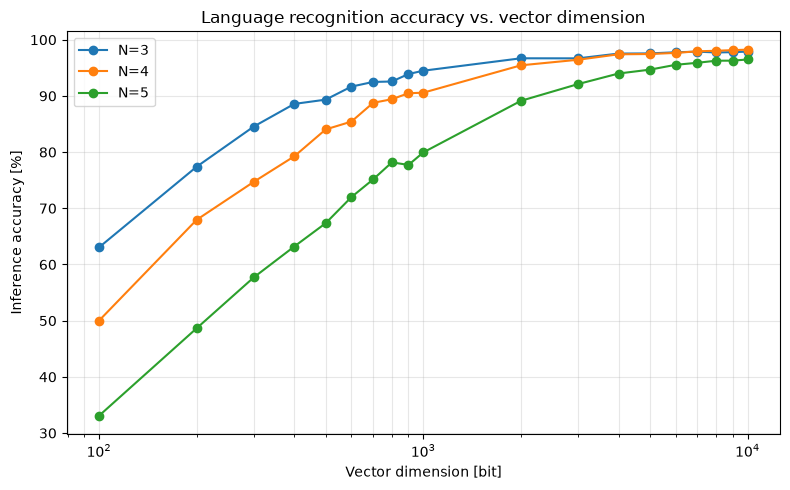

In [5]:
accuracy_by_n = {n_gram_size: {} for n_gram_size in n_gram_sizes}
for dimension, n_gram_size, acc in results:
    accuracy_by_n[n_gram_size][dimension] = acc

plt.figure(figsize=(8, 5))
for n_gram_size in n_gram_sizes:
    xs = sorted(accuracy_by_n[n_gram_size])
    ys = [accuracy_by_n[n_gram_size][d] * 100 for d in xs]
    plt.plot(xs, ys, marker='o', label=f"N={n_gram_size}")

plt.xscale('log')
plt.xlabel("Vector dimension [bit]")
plt.ylabel("Inference accuracy [%]")
plt.title("Language recognition accuracy vs. vector dimension")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_dimension.png", dpi=150)
plt.show()